# Visualizaciones

In [2]:
from pyspark.sql import SparkSession, functions as F, types as T
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

spark = (
    SparkSession.builder
    .appName("eda_musicbrainz")
    .config("spark.driver.memory", "2g")
    .enableHiveSupport()
    .getOrCreate()
)

ANL = "/Obligatorio/analytics"

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


2026-06-25T01:59:58,561 WARN [Thread-4] org.apache.hadoop.util.NativeCodeLoader - Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
2026-06-25T01:59:59,759 WARN [Thread-4] org.apache.spark.util.Utils - Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## Pregunta 1: Top festivales por accesibilidad aérea (barras horizontales):

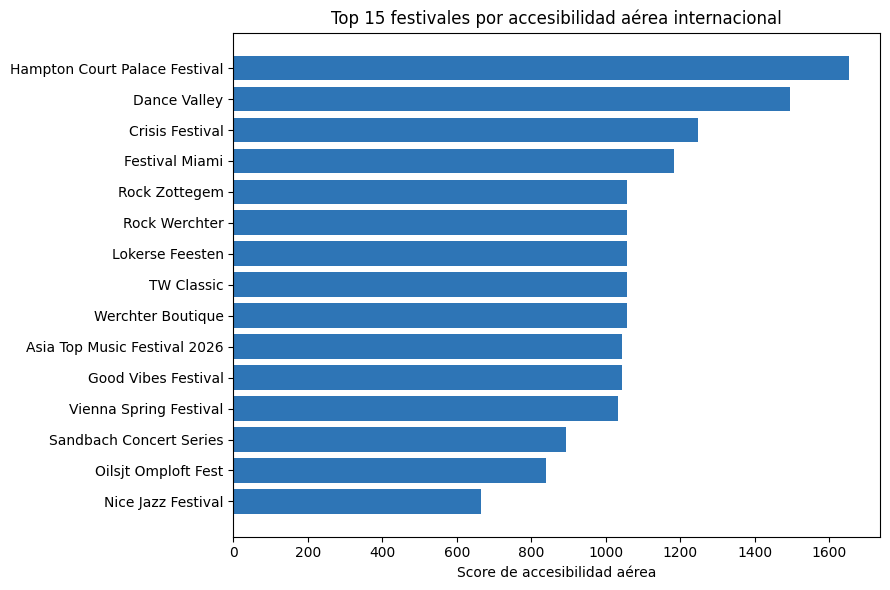

In [3]:
pdf1 = spark.read.parquet(f"{ANL}/q1_accesibilidad").toPandas().sort_values("accesibilidad").tail(15)
plt.figure(figsize=(9,6))
plt.barh(pdf1["festival_name"], pdf1["accesibilidad"], color="#2E75B6")
plt.xlabel("Score de accesibilidad aérea")
plt.title("Top 15 festivales por accesibilidad aérea internacional")
plt.tight_layout(); plt.show()

## Pregunta 3: Estacionalidad operativa (líneas, con temporada alta resaltada):

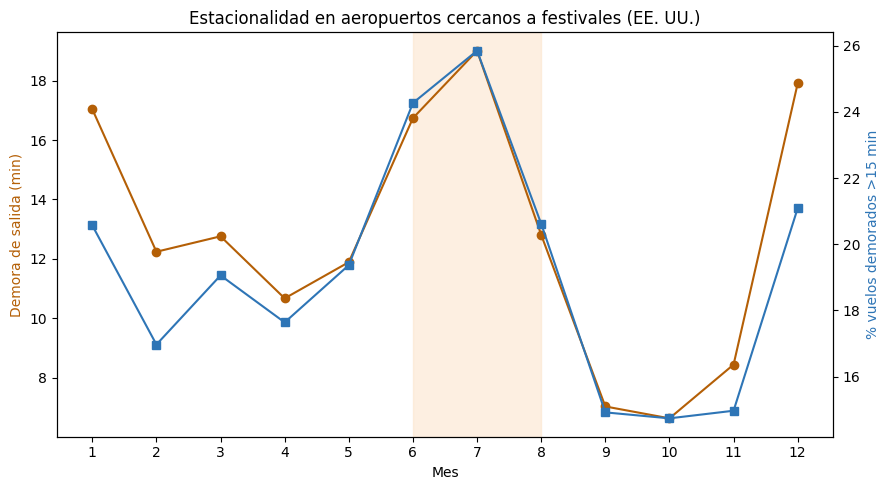

In [4]:
pdf3 = spark.read.parquet(f"{ANL}/q3_estacionalidad_mensual").toPandas().sort_values("mes")
fig, ax1 = plt.subplots(figsize=(9,5))
ax1.axvspan(6, 8, color="#FCE5CD", alpha=0.6)                       # jun-ago
ax1.plot(pdf3["mes"], pdf3["demora_salida_min"], marker="o", color="#B45F06", label="Demora salida (min)")
ax1.set_xlabel("Mes"); ax1.set_ylabel("Demora de salida (min)", color="#B45F06")
ax1.set_xticks(range(1,13))
ax2 = ax1.twinx()
ax2.plot(pdf3["mes"], pdf3["pct_demorados_15"], marker="s", color="#2E75B6", label="% demorados >15 min")
ax2.set_ylabel("% vuelos demorados >15 min", color="#2E75B6")
plt.title("Estacionalidad en aeropuertos cercanos a festivales (EE. UU.)")
fig.tight_layout(); plt.show()


## Pregunta 5: Países visitados según si la gira incluyó Uruguay (barras agrupadas):


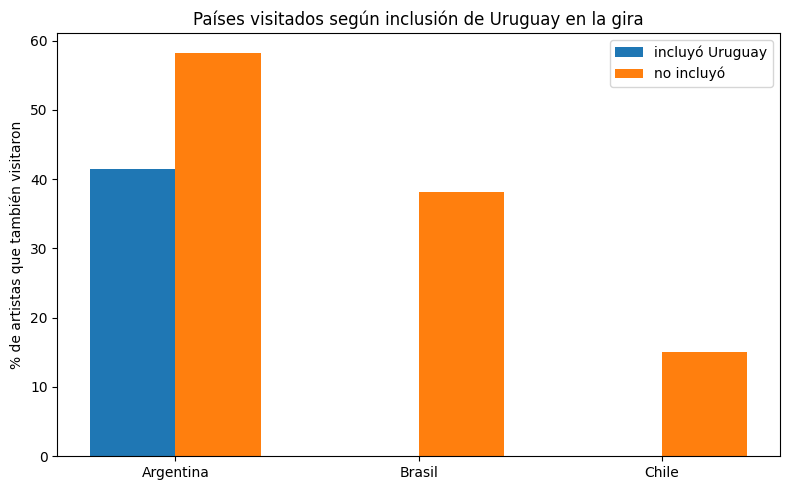

In [5]:
pdf5 = spark.read.parquet(f"{ANL}/q5_uruguay").toPandas()
cats = ["pct_argentina","pct_brasil","pct_chile"]; etiquetas = ["Argentina","Brasil","Chile"]
x = np.arange(len(cats)); w = 0.35
fig, ax = plt.subplots(figsize=(8,5))
for i, g in enumerate(pdf5["grupo"]):
    vals = pdf5[pdf5["grupo"] == g][cats].values.flatten()
    ax.bar(x + (i-0.5)*w, vals, w, label=g)
ax.set_xticks(x); ax.set_xticklabels(etiquetas)
ax.set_ylabel("% de artistas que también visitaron")
ax.set_title("Países visitados según inclusión de Uruguay en la gira")
ax.legend(); plt.tight_layout(); plt.show()
